Saving style.jpg to style.jpg
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Step: 0 Loss: 1.3084517e+18
Step: 10 Loss: 2.3878613e+17
Step: 20 Loss: 1.0264381e+17
Step: 30 Loss: 5.625709e+16
Step: 40 Loss: 3.4317334e+16
Step: 50 Loss: 2.309157e+16
Step: 60 Loss: 1.7167538e+16
Step: 70 Loss: 1.3430127e+16
Step: 80 Loss: 1.0940538e+16
Step: 90 Loss: 9194111000000000.0


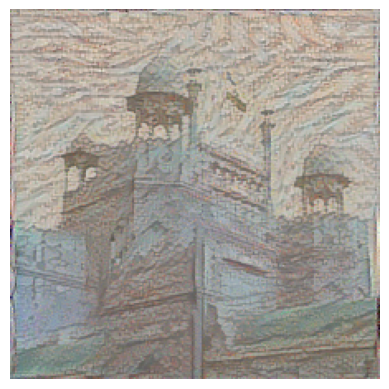

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# Neural Style Transfer (All in One Cell)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from google.colab import files

# Upload images
uploaded = files.upload()

# Image loader
def load_img(path):
    img = image.load_img(path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

content_image = load_img("content.jpg")
style_image = load_img("style.jpg")

# Load VGG19
vgg = VGG19(weights='imagenet', include_top=False)

for layer in vgg.layers:
    layer.trainable = False

# Layers
content_layer = ['block5_conv2']
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# Model
outputs = [vgg.get_layer(name).output for name in (style_layers + content_layer)]
model = tf.keras.Model([vgg.input], outputs)

# Loss functions
def content_loss(content, generated):
    return tf.reduce_mean(tf.square(content - generated))

def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    return tf.matmul(x, x, transpose_a=True)

def style_loss(style, generated):
    S = gram_matrix(style)
    G = gram_matrix(generated)
    return tf.reduce_mean(tf.square(S - G))

# Optimization
generated_image = tf.Variable(content_image, dtype=tf.float32)
optimizer = tf.optimizers.Adam(learning_rate=5.0)

# Training
for i in range(100):

    with tf.GradientTape() as tape:

        outputs = model(generated_image)

        style_outputs = outputs[:5]
        content_output = outputs[5]

        style_targets = model(style_image)[:5]
        content_target = model(content_image)[5]

        loss = 0

        for s, g in zip(style_targets, style_outputs):
            loss += style_loss(s, g)

        loss += content_loss(content_target, content_output)

    grad = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grad, generated_image)])

    if i % 10 == 0:
        print("Step:", i, "Loss:", loss.numpy())

# Show result
output = generated_image.numpy()[0]
output = (output - output.min()) / (output.max() - output.min())

plt.imshow(output)
plt.axis("off")
plt.show()

# Save and download
plt.imsave("stylized_output.png", output)
files.download("stylized_output.png")